In [15]:
# ═══════════════════════════════════════
# CELL 1 — Libraries
# ═══════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
print("✅ Libraries ready!")

✅ Libraries ready!


In [16]:
# Paste this in a NEW cell to test connection
import pandas as pd

sheet_id = "1PlSXLpjz6K9CyLo2dJdB5lv7eObISThzV7AiNSCbWPU"
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv"

try:
    df = pd.read_csv(url)
    print("✅ Connection successful!")
    print(f"Rows: {len(df)}")
    print(df.head())  # shows first 5 rows
except Exception as e:
    print(f"❌ Error: {e}")
    print("Fix: Make sheet public — Anyone with link = Viewer")

✅ Connection successful!
Rows: 11
   lead_id          source  enrolled    city  total_visits  time_on_site  \
0        1          Google         1    Pune             9          2500   
1        2        Meta Ads         0  Mumbai             2           400   
2        3  Organic Search         1   Delhi            11          2900   
3        4         YouTube         0  Nashik             1           200   
4        5          Google         1    Pune             8          1800   

  lead_quality last_activity            occupation  
0         Hot   Phone Called  Working Professional  
1         Warm    Email Sent               Student  
2         Hot       SMS Sent  Working Professional  
3         Cold  Email Opened               Student  
4         Hot   Phone Called  Working Professional  


In [17]:
# ═══════════════════════════════════════
# CELL 2 — Load LIVE Google Sheets Data
# ═══════════════════════════════════════
import pandas as pd


# Your Google Sheet ID (already filled!)
sheet_id = "1PlSXLpjz6K9CyLo2dJdB5lv7eObISThzV7AiNSCbWPU"

# This URL always gets latest data
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv"

# Load live data
df = pd.read_csv(url)

print(f"✅ Live data loaded!")
print(f"📊 Rows    : {len(df)}")
print(f"📋 Columns : {list(df.columns)}")
print(f"🕐 Loaded at: {pd.Timestamp.now()}")




✅ Live data loaded!
📊 Rows    : 11
📋 Columns : ['lead_id', 'source', 'enrolled', 'city', 'total_visits', 'time_on_site', 'lead_quality', 'last_activity', 'occupation']
🕐 Loaded at: 2026-03-19 12:03:45.864562


In [18]:
# ═══════════════════════════════════════
# CELL 3 — Create called Column
# ═══════════════════════════════════════
df['called'] = df['last_activity'].isin([
    'SMS Sent', 'Email Sent', 'Phone Called',
    'Olark Chat Conversation', 'Email Opened',
    'Email Link Clicked'
])
print("✅ called column created!")
print(df['called'].value_counts())

✅ called column created!
called
True    11
Name: count, dtype: int64


In [19]:
# ═══════════════════════════════════════
# CELL 4 — Lead Score
# ═══════════════════════════════════════
df['visits_score'] = (df['total_visits'].clip(0,10)/10*30).fillna(0)
df['time_score']   = (df['time_on_site'].clip(0,3000)/3000*30).fillna(0)
df['source_score'] = df['source'].apply(
    lambda x: 20 if x in ['Organic Search','Google','Referral'] else 0)
df['occ_score']    = df['occupation'].apply(
    lambda x: 20 if x == 'Working Professional' else 0)
df['lead_score'] = (
    df['visits_score'] + df['time_score'] +
    df['source_score'] + df['occ_score']
).round(1)
print("✅ Lead Score created!")
print(df['lead_score'].describe().round(1))

✅ Lead Score created!
count    11.0
mean     58.4
std      35.4
min       5.0
25%      28.0
50%      67.0
75%      87.0
max      99.0
Name: lead_score, dtype: float64


In [20]:
# ═══════════════════════════════════════
# CELL 5 — Priority Buckets
# ═══════════════════════════════════════
df['priority'] = pd.cut(
    df['lead_score'],
    bins=[-1, 30, 50, 100],
    labels=['Low', 'Medium', 'High']
)
print("✅ Priority created!")
print(df['priority'].value_counts())

✅ Priority created!
priority
High      7
Low       3
Medium    1
Name: count, dtype: int64


In [21]:
# ═══════════════════════════════════════
# CELL 6 — 4 Stage Funnel
# ═══════════════════════════════════════
total       = len(df)
crm_entered = df['lead_quality'].notna().sum()
contacted   = df['called'].sum()
enrolled    = df['enrolled'].sum()

print("======= 4-STAGE FUNNEL — MIT SDE (LIVE) =======")
print(f"Stage 1 | Total Leads : {total:,}        (100%)")
print(f"Stage 2 | CRM Entry   : {crm_entered:,}  ({crm_entered/total*100:.1f}%)")
print(f"Stage 3 | Contacted   : {contacted:,}    ({contacted/total*100:.1f}%)")
print(f"Stage 4 | Enrolled    : {enrolled:,}     ({enrolled/total*100:.1f}%)")
print("=================================================")
print(f"\nLeads never contacted : {total-contacted:,} lost!")

======= 4-STAGE FUNNEL — MIT SDE (LIVE) =======
Stage 1 | Total Leads : 11        (100%)
Stage 2 | CRM Entry   : 11  (100.0%)
Stage 3 | Contacted   : 11    (100.0%)
Stage 4 | Enrolled    : 6     (54.5%)

Leads never contacted : 0 lost!


  source_clean  total_leads  total_enrol  conv_rate
Organic Search            2            2      100.0
        Google            3            2       66.7
      Meta Ads            2            1       50.0
       YouTube            2            1       50.0
         Other            1            0        0.0
      Referral            1            0        0.0


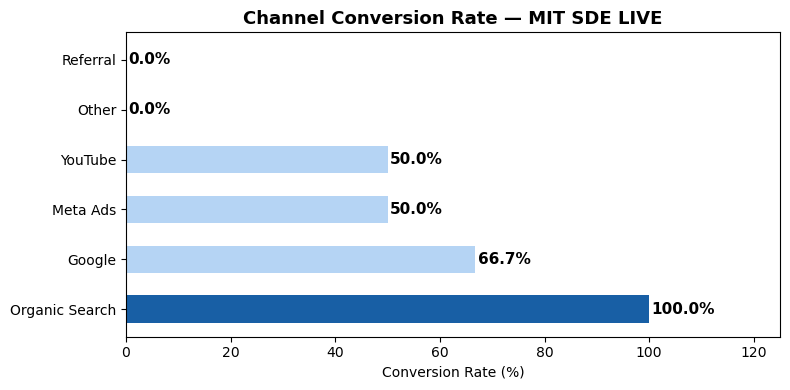

In [22]:
# ═══════════════════════════════════════
# CELL 7 — Channel Performance
# ═══════════════════════════════════════
top_sources = df['source'].value_counts().head(5).index.tolist()
df['source_clean'] = df['source'].apply(
    lambda x: x if x in top_sources else 'Other')

channel_stats = df.groupby('source_clean').agg(
    total_leads = ('lead_id', 'count'),
    total_enrol = ('enrolled', 'sum')
).reset_index()
channel_stats['conv_rate'] = (
    channel_stats['total_enrol'] /
    channel_stats['total_leads'] * 100
).round(1)
channel_stats = channel_stats.sort_values(
    'conv_rate', ascending=False).reset_index(drop=True)
print(channel_stats.to_string(index=False))

# Bar Chart
colors = ['#185FA5' if v == channel_stats['conv_rate'].max()
          else '#B5D4F4' for v in channel_stats['conv_rate']]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(channel_stats['source_clean'],
               channel_stats['conv_rate'],
               color=colors, height=0.55)
for bar, val in zip(bars, channel_stats['conv_rate']):
    ax.text(bar.get_width()+0.5,
            bar.get_y()+bar.get_height()/2,
            f'{val}%', va='center',
            fontsize=11, fontweight='bold')
ax.set_xlabel('Conversion Rate (%)')
ax.set_title('Channel Conversion Rate — MIT SDE LIVE',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, channel_stats['conv_rate'].max()*1.25)
plt.tight_layout()
plt.show()


In [23]:
# ═══════════════════════════════════════
# CELL 8 — Top 10 High Priority Leads
# ═══════════════════════════════════════
top_10 = df[df['priority'] == 'High']\
    .sort_values('lead_score', ascending=False)\
    .head(10)
print("TOP 10 LEADS — CALL THESE FIRST:")
print(top_10[[
    'lead_id', 'source',
    'city', 'occupation', 'lead_score'
]].to_string(index=False))

TOP 10 LEADS — CALL THESE FIRST:
 lead_id         source   city           occupation  lead_score
       3 Organic Search  Delhi Working Professional        99.0
       9 Organic Search Mumbai Working Professional        98.0
       1         Google   Pune Working Professional        92.0
       5         Google   Pune Working Professional        82.0
      11        YouTube   Pune Working Professional        72.0
       6       Referral Mumbai Working Professional        67.0
      10         Google  Delhi Working Professional        61.0


===== WEEKLY REPORT — MIT SDE LIVE =====
Total Leads   : 11
CRM Entry     : 11 (100.0%)
Contacted     : 11 (100.0%)
Enrolled      : 6 (54.5%)
High Priority : 7 leads


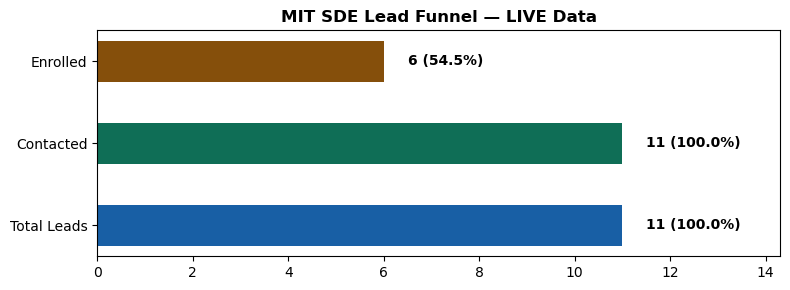

✅ Live weekly report complete!


In [24]:
# ═══════════════════════════════════════
# CELL 9 — Final Weekly Report
# ═══════════════════════════════════════
high_pri = (df['priority'] == 'High').sum()

print("===== WEEKLY REPORT — MIT SDE LIVE =====")
print(f"Total Leads   : {total:,}")
print(f"CRM Entry     : {crm_entered:,} ({crm_entered/total*100:.1f}%)")
print(f"Contacted     : {contacted:,} ({contacted/total*100:.1f}%)")
print(f"Enrolled      : {enrolled:,} ({enrolled/total*100:.1f}%)")
print(f"High Priority : {high_pri:,} leads")
print("=========================================")

# Funnel Chart
stages = ['Total Leads', 'Contacted', 'Enrolled']
values = [total, contacted, enrolled]
plt.figure(figsize=(8,3))
bars = plt.barh(stages, values,
    color=['#185FA5','#0F6E56','#854F0B'], height=0.5)
for bar, val in zip(bars, values):
    pct = val/total*100
    plt.text(bar.get_width()+0.5,
             bar.get_y()+bar.get_height()/2,
             f'{val:,} ({pct:.1f}%)',
             va='center', fontweight='bold')
plt.title('MIT SDE Lead Funnel — LIVE Data',
          fontweight='bold')
plt.xlim(0, total*1.3)
plt.tight_layout()
plt.show()
print("✅ Live weekly report complete!")